In [1]:
from Autograd import Tensor
from Activation import ReLU
from Loss import mean_squared_error,cross_entropy_loss
from Training import training
from Model import Sequential,Linear
from Optimiser import SGD,Momentum,RMSProp,Adagrad,Adadelta,Adam
from Testing import non_hot_one_accuracy
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def make_spiral(n_points=1000, n_classes=3, noise=0.2, seed=42):
    np.random.seed(seed)
    X=np.zeros((n_points*n_classes,2))
    y=np.zeros(n_points*n_classes,dtype=np.int64)
    for j in range(n_classes):
        ix=range(n_points*j,n_points*(j+1))
        r=np.linspace(0.0,1,n_points)
        t=np.linspace(j*4,(j+1)*4,n_points)
        t+=np.random.randn(n_points)*noise
        X[ix]=np.c_[r*np.sin(t),r*np.cos(t)]
        y[ix]=j
    return X,y

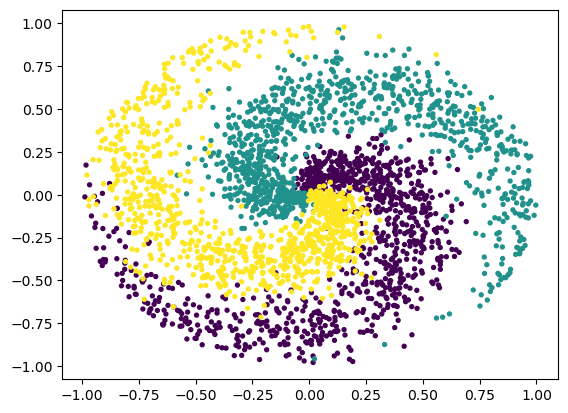

In [3]:
from sklearn.model_selection import train_test_split

no_classes=3
coords,classes=make_spiral(1000,no_classes,0.5)
plt.scatter(coords[:,0],coords[:,1],c=classes,s=8)
coords,classes=Tensor(coords),Tensor(classes)

coords_train,coords_test,class_train,class_test=train_test_split(coords,classes,test_size=0.2,random_state=42)

no_samples=coords.shape[0]
no_features=coords.shape[1]

In [10]:
loss_fn=cross_entropy_loss
epochs=500
batch_size=64

SGD_model=Sequential([Linear(no_features,15),ReLU(),Linear(15,5),ReLU(),Linear(5,3)])
optimiser=SGD(SGD_model.parameters(),lr=0.1)
SGDloss=training(coords_train,SGD_model,class_train,loss_fn,epochs,optimiser,batch_size)

Momentum_model=Sequential([Linear(no_features,15),ReLU(),Linear(15,5),ReLU(),Linear(5,3)])
optimiser=Momentum(Momentum_model.parameters(),lr=0.1,beta=0.9)
Momentumloss=training(coords_train,Momentum_model,class_train,loss_fn,epochs,optimiser,batch_size)

Adagrad_model=Sequential([Linear(no_features,15),ReLU(),Linear(15,5),ReLU(),Linear(5,3)])
optimiser=Adagrad(Adagrad_model.parameters(),lr=0.1,eta=0.9)
Adagradloss=training(coords_train,Adagrad_model,class_train,loss_fn,epochs,optimiser,batch_size)

RMSProp_model=Sequential([Linear(no_features,15),ReLU(),Linear(15,5),ReLU(),Linear(5,3)])
optimiser=RMSProp(RMSProp_model.parameters(),lr=0.005,gamma=0.9)
RMSProploss=training(coords_train,RMSProp_model,class_train,loss_fn,epochs,optimiser,batch_size)

Adadelta_model=Sequential([Linear(no_features,15),ReLU(),Linear(15,5),ReLU(),Linear(5,3)])
optimiser=Adadelta(Adadelta_model.parameters(),rho=0.95)
Adadeltaloss=training(coords_train,Adadelta_model,class_train,loss_fn,epochs,optimiser,batch_size)

Adam_model=Sequential([Linear(no_features,15),ReLU(),Linear(15,5),ReLU(),Linear(5,3)])
optimiser=Adam(Adam_model.parameters(),lr=0.01,beta1=0.9,beta2=0.999)
Adamloss=training(coords_train,Adam_model,class_train,loss_fn,epochs,optimiser,batch_size)

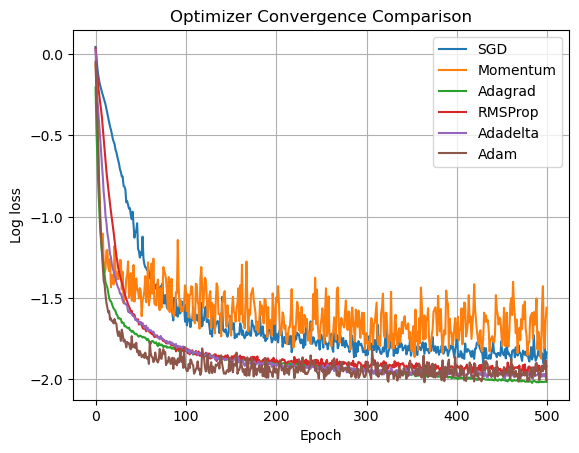

In [11]:
plt.plot(np.log(SGDloss),label="SGD")
plt.plot(np.log(Momentumloss),label="Momentum")
plt.plot(np.log(Adagradloss),label="Adagrad")
plt.plot(np.log(RMSProploss),label="RMSProp")
plt.plot(np.log(Adadeltaloss),label="Adadelta")
plt.plot(np.log(Adamloss),label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Log loss")
plt.title("Optimizer Convergence Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [12]:
print("SGD final training loss and accuracy: ",SGDloss[-1],non_hot_one_accuracy(SGD_model.forward_prop(coords_train),class_train))
print("Momentum final training loss and accuracy: ",Momentumloss[-1],non_hot_one_accuracy(Momentum_model.forward_prop(coords_train),class_train))
print("Adagrad final training loss and accuracy: ",Adagradloss[-1],non_hot_one_accuracy(Adagrad_model.forward_prop(coords_train),class_train))
print("RMSProp final training loss and accuracy: ",RMSProploss[-1],non_hot_one_accuracy(RMSProp_model.forward_prop(coords_train),class_train))
print("Adadelta final training loss and accuracy: ",Adadeltaloss[-1],non_hot_one_accuracy(Adadelta_model.forward_prop(coords_train),class_train))
print("Adam final training loss and accuracy: ",Adamloss[-1],non_hot_one_accuracy(Adam_model.forward_prop(coords_train),class_train))

SGD final training loss and accuracy:  0.15989074042332552 0.93375
Momentum final training loss and accuracy:  0.21028712202558775 0.9429166666666666
Adagrad final training loss and accuracy:  0.13333578515600192 0.9558333333333333
RMSProp final training loss and accuracy:  0.14681636341093662 0.94875
Adadelta final training loss and accuracy:  0.13537058521449027 0.9470833333333334
Adam final training loss and accuracy:  0.1346646456991703 0.9570833333333333


In [13]:
SGDtest=SGD_model.forward_prop(coords_test)
Momentumtest=Momentum_model.forward_prop(coords_test)
Adagradtest=Adagrad_model.forward_prop(coords_test)
RMSProptest=RMSProp_model.forward_prop(coords_test)
Adadeltatest=Adadelta_model.forward_prop(coords_test)
Adamtest=Adam_model.forward_prop(coords_test)

SGDLoss=cross_entropy_loss(SGDtest,class_test)
MomentumLoss=cross_entropy_loss(Momentumtest,class_test)
AdagradLoss=cross_entropy_loss(Adagradtest,class_test)
RMSPropLoss=cross_entropy_loss(RMSProptest,class_test)
AdadeltaLoss=cross_entropy_loss(Adadeltatest,class_test)
AdamLoss=cross_entropy_loss(Adamtest,class_test)

SGDAccuracy=non_hot_one_accuracy(SGDtest,class_test)
MomentumAccuracy=non_hot_one_accuracy(Momentumtest,class_test)
AdagradAccuracy=non_hot_one_accuracy(Adagradtest,class_test)
RMSPropAccuracy=non_hot_one_accuracy(RMSProptest,class_test)
AdadeltaAccuracy=non_hot_one_accuracy(Adadeltatest,class_test)
AdamAccuracy=non_hot_one_accuracy(Adamtest,class_test)

print(SGDLoss.data,SGDAccuracy)
print(MomentumLoss.data,MomentumAccuracy)
print(AdagradLoss.data,AdagradAccuracy)
print(RMSPropLoss.data,RMSPropAccuracy)
print(AdadeltaLoss.data,AdadeltaAccuracy)
print(AdamLoss.data,AdamAccuracy)

0.2065599761157014 0.935
0.17489982558753306 0.9366666666666666
0.15242426279845125 0.955
0.1750009054076187 0.94
0.15914934359181174 0.95
0.1525535211784593 0.955
